# Assignment 6: Experiment Tracking and Hyperparameter Optimization

---
_**Team 06**_

Name | Roll Number
---|---
Aditya Prakash Borate| 23110065
Swayam Giridhar Borate | 23110066

---

Github Repository : https://github.com/adi776borate/CS203-STT-Labs/tree/main/CS203_Lab_06

# Section 2 : Hyperparameters

## Importing Necessary Libraries

In [1]:
!pip install autogluon -q

In [2]:
!pip install watermark

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from autogluon.tabular import TabularDataset, TabularPredictor
from autogluon.common import space

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Print versions using watermark
%reload_ext watermark
%watermark -v -m -p numpy,pandas,matplotlib,seaborn,tensorflow,sklearn,autogluon

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 7.34.0

numpy     : 1.26.4
pandas    : 2.2.2
matplotlib: 3.10.0
seaborn   : 0.13.2
tensorflow: 2.18.0
sklearn   : 1.5.2
autogluon : 1.2

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.1.85+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [6]:
# Load and preprocess Iris dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)  # Reshape for one-hot encoding
X.shape, y.shape

((150, 4), (150, 1))

In [7]:
# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

In [8]:
# Normalize features to [0,1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [9]:
# Split dataset with stratification into train (70%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Further split into validation (10%) & test (20%) from remaining 30%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42)

In [10]:
# Check the no. of sample of each class in train, val, and test
print("Training data:")
unique_train, counts_train = np.unique(np.argmax(y_train, axis=1), return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nValidation data:")
unique_val, counts_val = np.unique(np.argmax(y_val, axis=1), return_counts=True)
for label, count in zip(unique_val, counts_val):
    print(f"Class {label}: {count} samples")

print("\nTest data:")
unique_test, counts_test = np.unique(np.argmax(y_test, axis=1), return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")


Training data:
Class 0: 35 samples
Class 1: 35 samples
Class 2: 35 samples

Validation data:
Class 0: 5 samples
Class 1: 5 samples
Class 2: 5 samples

Test data:
Class 0: 10 samples
Class 1: 10 samples
Class 2: 10 samples


## Task 1: Hyperparameter Optimization




## EDA on Iris Dataset

In [11]:
def explore_iris_data(X, y):
    """Explore the Iris dataset."""
    features = pd.DataFrame(X, columns=iris.feature_names)
    target = pd.Series(y.argmax(axis=1), name='target')  # Convert one-hot labels back to class indices

    print("\nData Overview:")
    print(f"Number of samples: {X.shape[0]}")
    print(f"Number of features: {X.shape[1]}")
    print("\nFeature Statistics:")
    display(features.describe())

    # Feature distributions
    plt.figure(figsize=(12, 8))
    for i, col in enumerate(features.columns, 1):
        plt.subplot(2, 2, i)
        sns.histplot(data=features, x=col, bins=30)
        plt.title(f'{col} Distribution')
    plt.tight_layout()
    plt.show()

    # Correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
    plt.title('Feature Correlation Matrix')
    plt.show()

    # Target distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target)
    plt.title('Target Class Distribution')
    plt.show()

    return features, target



Data Overview:
Number of samples: 150
Number of features: 4

Feature Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


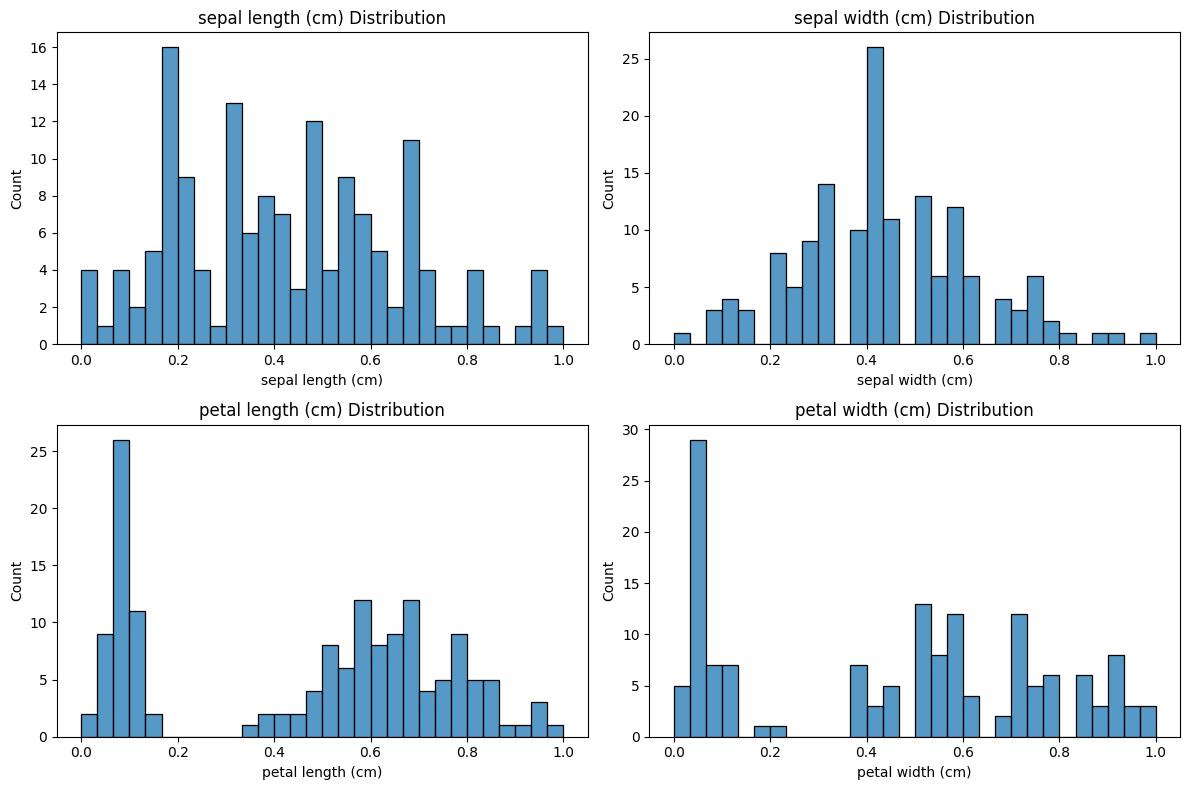

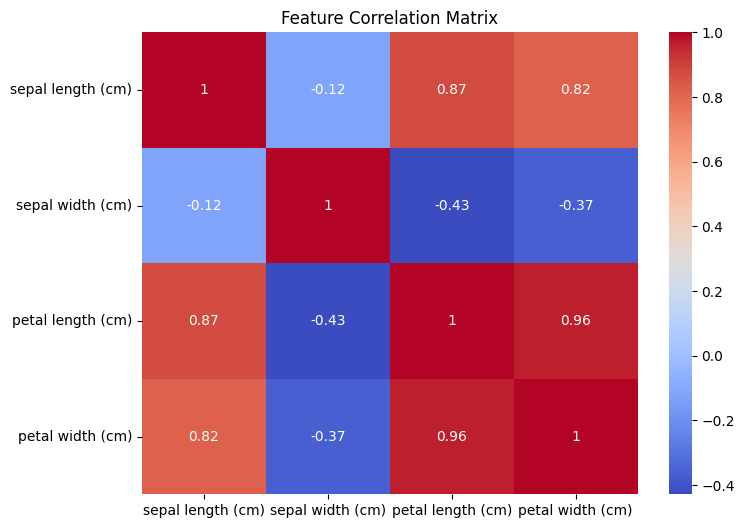

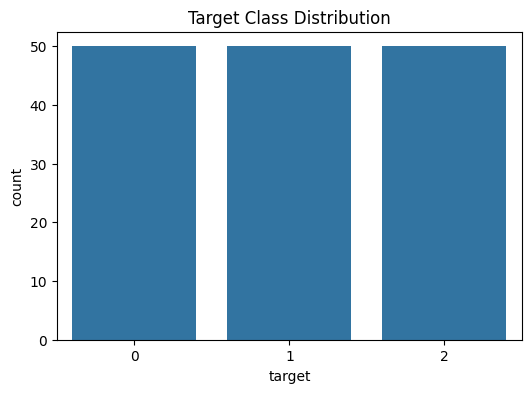

In [12]:
# Explore Iris dataset
features, target = explore_iris_data(X, y)

## Preparing the Data

In [13]:
def prepare_iris_data(X_train, X_val, X_test, y_train, y_val, y_test):
    """Prepare Iris dataset for AutoGluon using the predefined splits."""
    train_df = pd.DataFrame(X_train, columns=iris.feature_names)
    train_df['target'] = y_train.argmax(axis=1)

    val_df = pd.DataFrame(X_val, columns=iris.feature_names)
    val_df['target'] = y_val.argmax(axis=1)

    test_df = pd.DataFrame(X_test, columns=iris.feature_names)
    test_df['target'] = y_test.argmax(axis=1)

    # Convert to TabularDataset
    train_data = TabularDataset(train_df)
    val_data = TabularDataset(val_df)
    test_data = TabularDataset(test_df)

    print("\nData Split Information:")
    print(f"Training samples: {len(train_data)}")
    print(f"Validation samples: {len(val_data)}")
    print(f"Testing samples: {len(test_data)}")
    print("\nClass distribution in training:")
    print(train_df['target'].value_counts(normalize=True))

    return train_data, val_data, test_data

In [14]:
# Prepare Iris Tabular Dataset
train_data, val_data, test_data = prepare_iris_data(X_train, X_val, X_test, y_train, y_val, y_test)
print("\nIris data preparation completed!")


Data Split Information:
Training samples: 105
Validation samples: 15
Testing samples: 30

Class distribution in training:
target
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64

Iris data preparation completed!


## Manual HPO

In [15]:
# Hyperparameters
batch_sizes = [2, 4]
learning_rates = [1e-3, 1e-5]
epochs_list = [1, 3, 5]

In [16]:
# Hyperparameter Optimization
def hyperparameter_optimization(train_data, test_data):
    """Perform hyperparameter optimization with different configurations while keeping track of the best configuration."""
    results = []
    predictors = []
    best_model = None
    best_score = 0
    best_params = None
    confusion_matrices = []

    for batch_size in batch_sizes:
        for lr in learning_rates:
            for epochs in epochs_list:
                model_path = f"models/hpo_nn_torch/models/hpo_nn_torch_bs{batch_size}_lr{lr}_epochs{epochs}"
                os.makedirs(model_path, exist_ok=True)  # Ensure unique directory for each model

                print(f"\nTraining model with batch_size={batch_size}, learning_rate={lr}, epochs={epochs}")

                # Train model
                predictor = TabularPredictor(label="target", eval_metric="accuracy", path=model_path, problem_type='multiclass').fit(
                    train_data=train_data,
                    hyperparameters={"NN_TORCH": {"num_epochs": epochs, "learning_rate": lr, "batch_size": batch_size}},
                    time_limit=600,
                    verbosity=1,
                    tuning_data=val_data,
                    use_bag_holdout=True,  # Validation data will be used for tuning
                )
                # Validation accuracy
                'Validation Accuracy':predictor.leaderboard().loc[0, 'score_val']


                # Evaluate on test set
                y_test = test_data["target"]
                y_pred = predictor.predict(test_data)
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average="macro")
                results.append((batch_size, lr, epochs, acc, f1))
                print(f"Accuracy: {acc:.4f}, F1-score: {f1:.4f}")

                # Track best model
                if acc > best_score:
                    best_score = acc
                    best_model = predictor
                    best_params = (batch_size, lr, epochs)

                # Store confusion matrix
                cm = confusion_matrix(y_test, y_pred)
                confusion_matrices.append((batch_size, lr, epochs, cm))

                # Storing all the predictors to extract training accuracy
                predictors.append(predictor)

    # Display results
    results_df = pd.DataFrame(results, columns=["Batch Size", "Learning Rate", "Epochs", "Accuracy", "F1 Score"])
    print("\nHyperparameter Optimization Results:")
    display(results_df)
    print()

    # Plot all confusion matrices in subplots
    num_matrices = len(confusion_matrices)
    cols = 3  # Number of columns in the subplot grid
    rows = (num_matrices // cols) + (num_matrices % cols > 0)  # Calculate required rows

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()  # Flatten in case we get a multi-dimensional array

    for i, (batch_size, lr, epochs, cm) in enumerate(confusion_matrices):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test),
                    ax=axes[i])
        axes[i].set_title(f"Batch={batch_size}, LR={lr}, Epochs={epochs}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # Show 5 sample predictions using the best model
    if best_model:
        print(f"\nUsing best hyperparameters: Batch={best_params[0]}, LR={best_params[1]}, Epochs={best_params[2]}")
        sample_test = test_data.sample(5, random_state=42)
        sample_test["predicted"] = best_model.predict(sample_test.drop(columns=["target"]))
        print("\nSample Predictions:")
        display(sample_test)


Training model with batch_size=2, learning_rate=0.001, epochs=1


Accuracy: 0.7667, F1-score: 0.7341

Training model with batch_size=2, learning_rate=0.001, epochs=3


Accuracy: 1.0000, F1-score: 1.0000

Training model with batch_size=2, learning_rate=0.001, epochs=5


Accuracy: 1.0000, F1-score: 1.0000

Training model with batch_size=2, learning_rate=1e-05, epochs=1
Accuracy: 0.4333, F1-score: 0.3467

Training model with batch_size=2, learning_rate=1e-05, epochs=3


Accuracy: 0.5667, F1-score: 0.4743

Training model with batch_size=2, learning_rate=1e-05, epochs=5


Accuracy: 0.5667, F1-score: 0.4765

Training model with batch_size=4, learning_rate=0.001, epochs=1
Accuracy: 0.7333, F1-score: 0.6755

Training model with batch_size=4, learning_rate=0.001, epochs=3


Accuracy: 1.0000, F1-score: 1.0000

Training model with batch_size=4, learning_rate=0.001, epochs=5


Accuracy: 1.0000, F1-score: 1.0000

Training model with batch_size=4, learning_rate=1e-05, epochs=1
Accuracy: 0.3667, F1-score: 0.2802

Training model with batch_size=4, learning_rate=1e-05, epochs=3


Accuracy: 0.5333, F1-score: 0.4394

Training model with batch_size=4, learning_rate=1e-05, epochs=5
Accuracy: 0.5667, F1-score: 0.4743

Hyperparameter Optimization Results:


,Batch Size,Learning Rate,Epochs,Accuracy,F1 Score
0,2,0.00100,1,0.766667,0.734093
1,2,0.00100,3,1.000000,1.000000
2,2,0.00100,5,1.000000,1.000000
3,2,0.00001,1,0.433333,0.346667
4,2,0.00001,3,0.566667,0.474250
5,2,0.00001,5,0.566667,0.476530
6,4,0.00100,1,0.733333,0.675485
7,4,0.00100,3,1.000000,1.000000
8,4,0.00100,5,1.000000,1.000000
9,4,0.00001,1,0.366667,0.280193


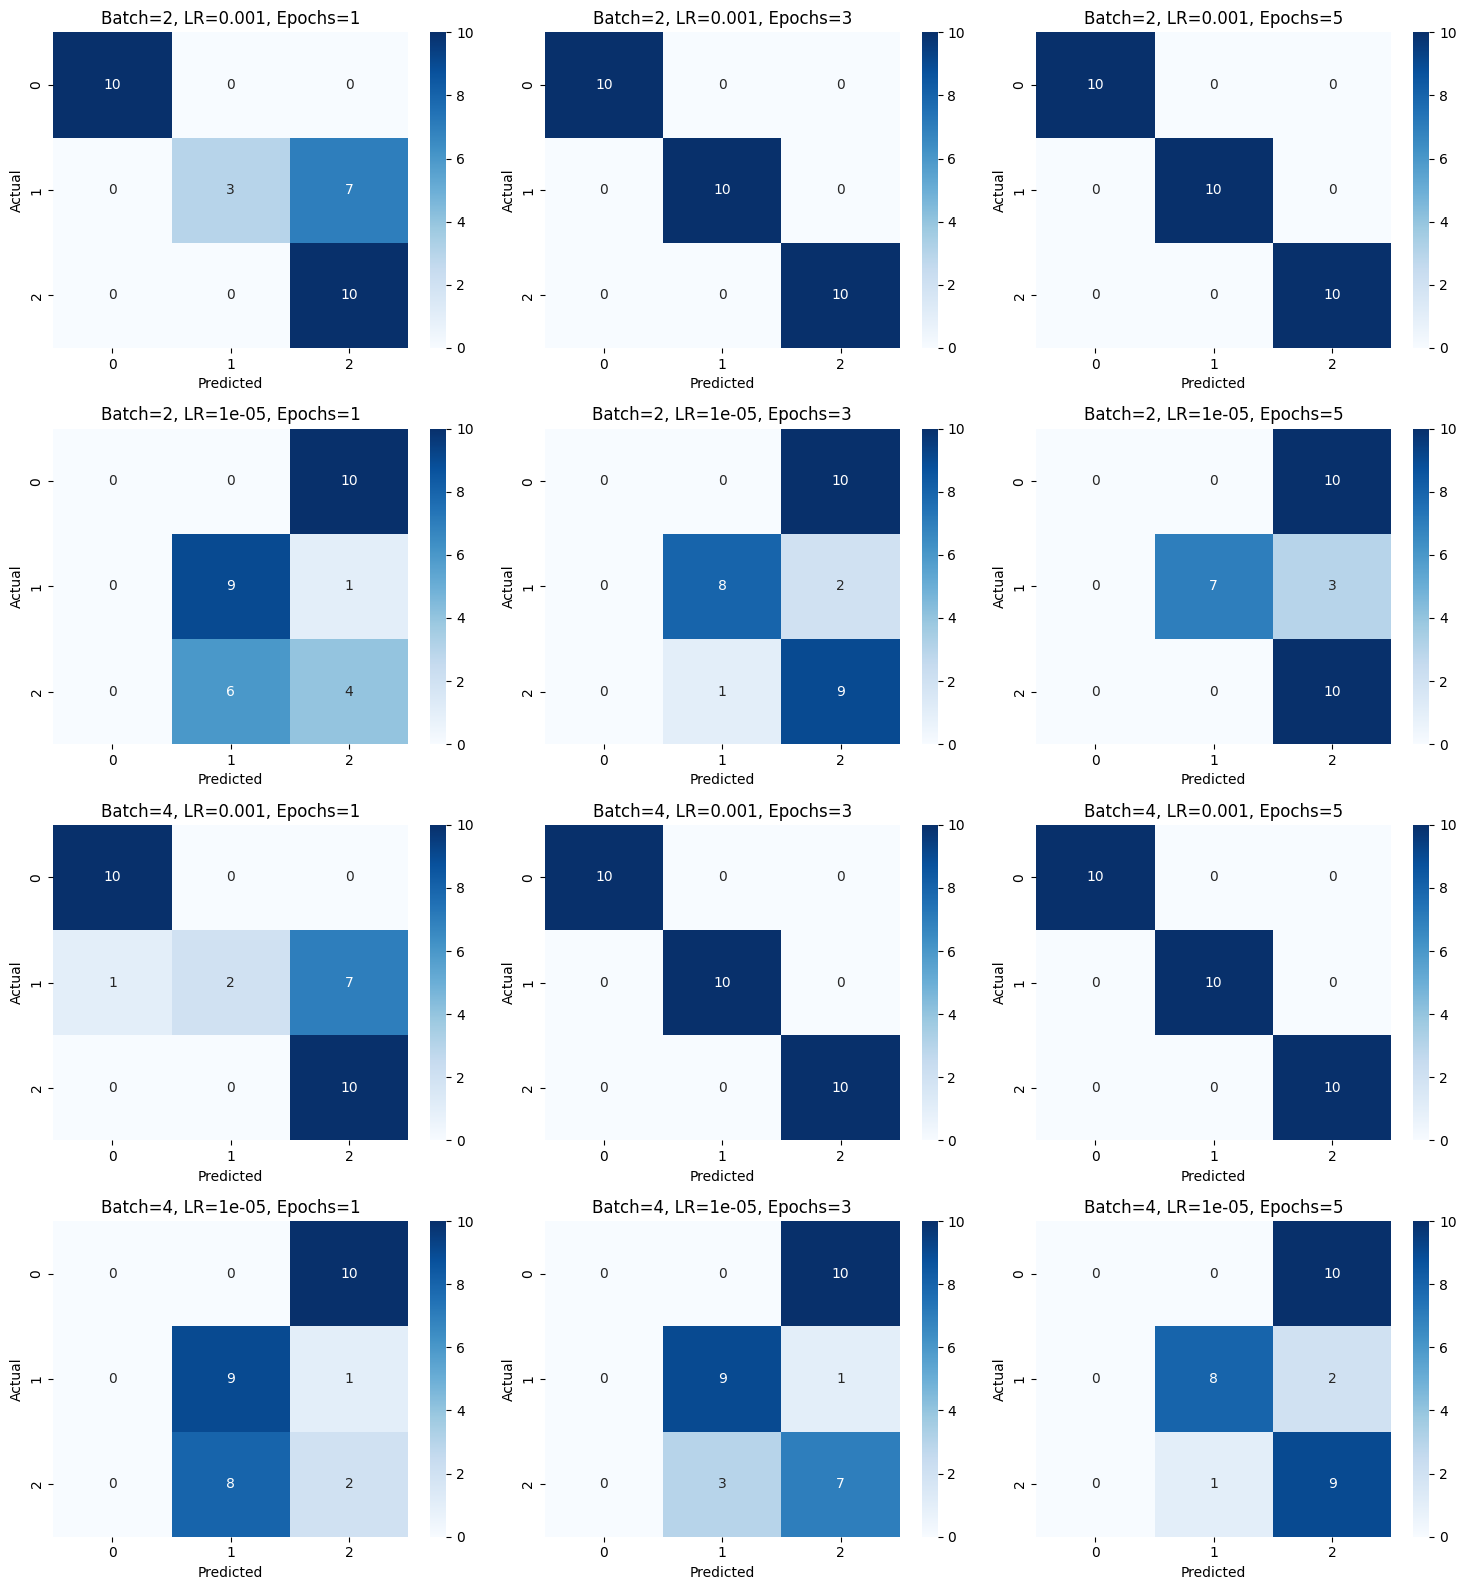


Using best hyperparameters: Batch=2, LR=0.001, Epochs=3

Sample Predictions:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,predicted
27,0.027778,0.375000,0.067797,0.041667,0,0
15,0.638889,0.375000,0.610169,0.500000,1,1
23,0.777778,0.416667,0.830508,0.833333,2,2
17,0.333333,0.125000,0.508475,0.500000,1,1
8,0.194444,0.583333,0.084746,0.041667,0,0


In [17]:
# Run hyperparameter optimization
hyperparameter_optimization(train_data, test_data)

## Task 2: Automated Hyperparameter Search

In [16]:
def get_model_parameters(predictor, test_data):
    """
    Extracts model parameters, train accuracy, and validation accuracy from a predictor.
    """
    leaderboard_df = predictor.leaderboard(test_data, silent=True)
    model_params_list = []

    for model_name in predictor.model_names():
        model = predictor._trainer.load_model(model_name)
        model_row = leaderboard_df.loc[leaderboard_df['model'] == model_name]
        train_accuracy = model_row['score_test'].values[0] if not model_row.empty else "N/A"
        val_accuracy = model_row['score_val'].values[0] if not model_row.empty else "N/A"

        params = {
            "Model Name": model_name,
            "Batch Size": model.params.get("batch_size", "N/A"),
            "Num Epochs": model.params.get("num_epochs", "N/A"),
            "Learning Rate": model.params.get("learning_rate", "N/A"),
            "Train Accuracy": train_accuracy,
            "Validation Accuracy": val_accuracy
        }
        model_params_list.append(params)

    return pd.DataFrame(model_params_list)

In [17]:
def plot_accuracy(accuracy_df):
    """Plot train accuracy vs validation accuracy for each hyperparameter combination."""
    plt.figure(figsize=(10, 6))

    for strategy in accuracy_df['Strategy'].unique():
        subset = accuracy_df[accuracy_df['Strategy'] == strategy]
        plt.scatter(subset['Train Accuracy'], subset['Validation Accuracy'], label=strategy, alpha=0.7)

    plt.xlabel("Training Accuracy")
    plt.ylabel("Validation Accuracy")
    plt.title("Training vs Validation Accuracy for Hyperparameter Combinations")
    plt.legend()
    plt.grid(True)
    plt.show()

In [18]:
def evaluate_hpo_models(models, test_data):
    """
    Evaluate and compare different hyperparameter tuning strategies.
    """
    y_test = test_data["target"]
    metrics = {"Strategy": [], "Metric": [], "Score": []}

    for name, predictor in models.items():
        y_pred = predictor.predict(test_data)
        metrics["Strategy"].extend([name, name])
        metrics["Metric"].extend(["Accuracy", "F1 Score"])
        metrics["Score"].extend([
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro")
        ])

    metrics_df = pd.DataFrame(metrics).pivot(index="Strategy", columns="Metric", values="Score").reset_index()

    print("\nModel Performance Comparison:")
    display(metrics_df)

    plt.figure(figsize=(10, 6))

    strategies = metrics_df["Strategy"].unique()
    metrics_labels = ["Accuracy", "F1 Score"]
    x = np.arange(len(metrics_labels))
    width = 0.15

    for i, strategy in enumerate(strategies):
        subset = metrics_df[metrics_df["Strategy"] == strategy][metrics_labels].values.flatten()
        plt.bar(x + i * width, subset, width, label=strategy)

    plt.xticks(x + width, metrics_labels)
    plt.title("HPO Strategy Performance Comparison")
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.legend(title="Strategies")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.show()

    return metrics_df

In [22]:
def automated_hyperparameter_search(train_data, val_data, test_data):
    """Perform hyperparameter tuning using various strategies."""
    nn_options = {
        "num_epochs": space.Categorical(1, 3, 5),
        "learning_rate": space.Categorical(1e-3, 1e-5),
        "batch_size": space.Categorical(2, 4),
    }
    hyperparameters = {"NN_TORCH": nn_options}

    nn_options_random_search = {
        "num_epochs": space.Real(1, 5),
        "learning_rate": space.Real(1e-5, 1e-3, log=True),
        "batch_size": space.Int(2, 4),
    }
    hyperparameters_random_search = {"NN_TORCH": nn_options_random_search}

    models = {}
    accuracy_results = []

    search_methods = {
        "Grid Search": {"searcher": "random", "scheduler": "FIFO", "num_trials": 12},
        "Random Search": {"searcher": "random", "scheduler": "FIFO", "num_trials": 5},
        "Hyperband": {"searcher": "random", "scheduler": "local", "num_trials": 12, "search_strategy": "hyperband", "grace_period": 1},
        "Bayesian Optimization": {"searcher": "bayes", "scheduler": "FIFO", "num_trials": 12},
        "Hyperband + Bayesian Optimization": {"searcher": "bayes", "scheduler": "local", "num_trials": 12, "search_strategy": "bayesopt_hyperband", "grace_period": 1}
    }

    for strategy, tune_kwargs in search_methods.items():
        model_path = f"models/hpo_{strategy.replace(' ', '_').lower()}"
        os.makedirs(model_path, exist_ok=True)
        print(f"\nStarting {strategy}...")

        hp_space = hyperparameters_random_search if strategy == "Random Search" else hyperparameters

        try:
            predictor = TabularPredictor(
                label="target", eval_metric="accuracy", path=model_path, problem_type="multiclass"
            )
            predictor.fit(
                train_data, hyperparameters=hp_space, hyperparameter_tune_kwargs=tune_kwargs,
                time_limit=3600, verbosity=1, tuning_data=val_data, use_bag_holdout=True
            )
            models[strategy] = predictor

            model_summary_df = get_model_parameters(predictor, test_data)
            print(model_summary_df)

            for _, row in model_summary_df.iterrows():
                accuracy_results.append({
                    'Strategy': strategy,
                    'Train Accuracy': row['Train Accuracy'],
                    'Validation Accuracy': row['Validation Accuracy']
                })

        except Exception as e:
            print(f"\nError during {strategy}: {str(e)}")
            continue

    accuracy_df = pd.DataFrame(accuracy_results)
    # Call the function to plot accuracy results
    plot_accuracy(accuracy_df)

    return evaluate_hpo_models(models, test_data)



Starting Grid Search...
+--------------------------------------------------------+
| Configuration for experiment     NeuralNetTorch        |
+--------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator |
| Scheduler                        FIFOScheduler         |
| Number of trials                 12                    |
+--------------------------------------------------------+

View detailed results here: /content/models/hpo_grid_search/models/NeuralNetTorch



                    Model Name Batch Size Num Epochs Learning Rate  \
0   NeuralNetTorch/f12b1_00000          2          1         0.001   
1   NeuralNetTorch/f12b1_00001          2          5         0.001   
2   NeuralNetTorch/f12b1_00002          2          1         0.001   
3   NeuralNetTorch/f12b1_00003          2          3       0.00001   
4   NeuralNetTorch/f12b1_00004          2          1       0.00001   
5   NeuralNetTorch/f12b1_00005          2          3       0.00001   
6   NeuralNetTorch/f12b1_00006          2          5       0.00001   
7   NeuralNetTorch/f12b1_00007          4          1         0.001   
8   NeuralNetTorch/f12b1_00008          2          3       0.00001   
9   NeuralNetTorch/f12b1_00009          4          1       0.00001   
10  NeuralNetTorch/f12b1_00010          2          1       0.00001   
11  NeuralNetTorch/f12b1_00011          2          5       0.00001   
12         WeightedEnsemble_L2        N/A        N/A           N/A   

    Train Accuracy 

                   Model Name Batch Size Num Epochs Learning Rate  \
0  NeuralNetTorch/32d3a_00000          2          1       0.00001   
1  NeuralNetTorch/32d3a_00001          3   4.992145      0.000308   
2  NeuralNetTorch/32d3a_00002          3   4.706231      0.000132   
3  NeuralNetTorch/32d3a_00003          2   4.657175      0.000559   
4  NeuralNetTorch/32d3a_00004          4    4.09985      0.000208   
5         WeightedEnsemble_L2        N/A        N/A           N/A   

   Train Accuracy  Validation Accuracy  
0        0.733333             0.733333  
1        1.000000             0.933333  
2        0.900000             0.933333  
3        1.000000             1.000000  
4        0.900000             0.933333  
5        1.000000             1.000000  

Starting Hyperband...
+--------------------------------------------------------+
| Configuration for experiment     NeuralNetTorch        |
+--------------------------------------------------------+
| Search algorithm           

                    Model Name Batch Size Num Epochs Learning Rate  \
0   NeuralNetTorch/4f1f1_00000          2          1         0.001   
1   NeuralNetTorch/4f1f1_00001          4          3         0.001   
2   NeuralNetTorch/4f1f1_00002          2          5       0.00001   
3   NeuralNetTorch/4f1f1_00003          2          3       0.00001   
4   NeuralNetTorch/4f1f1_00004          2          5         0.001   
5   NeuralNetTorch/4f1f1_00005          4          3       0.00001   
6   NeuralNetTorch/4f1f1_00006          2          5       0.00001   
7   NeuralNetTorch/4f1f1_00007          2          3         0.001   
8   NeuralNetTorch/4f1f1_00008          4          1         0.001   
9   NeuralNetTorch/4f1f1_00009          4          3         0.001   
10  NeuralNetTorch/4f1f1_00010          2          1       0.00001   
11  NeuralNetTorch/4f1f1_00011          4          5       0.00001   
12         WeightedEnsemble_L2        N/A        N/A           N/A   

    Train Accuracy 

                 Model Name Batch Size Num Epochs Learning Rate  \
0   NeuralNetTorch/0250e60a          2          1         0.001   
1   NeuralNetTorch/59b57770          2          5       0.00001   
2   NeuralNetTorch/c82733b5          2          3         0.001   
3   NeuralNetTorch/ee8edac5          4          1       0.00001   
4   NeuralNetTorch/01e6e9f0          2          3       0.00001   
5   NeuralNetTorch/56f8b044          4          5         0.001   
6   NeuralNetTorch/7ec64f6a          2          1         0.001   
7   NeuralNetTorch/e7d333af          4          1       0.00001   
8   NeuralNetTorch/31ad8492          4          5         0.001   
9   NeuralNetTorch/b80ebbb0          4          1       0.00001   
10  NeuralNetTorch/e6496c2f          2          1         0.001   
11  NeuralNetTorch/57cf24cd          2          5       0.00001   
12      WeightedEnsemble_L2        N/A        N/A           N/A   

    Train Accuracy  Validation Accuracy  
0         0.900000 

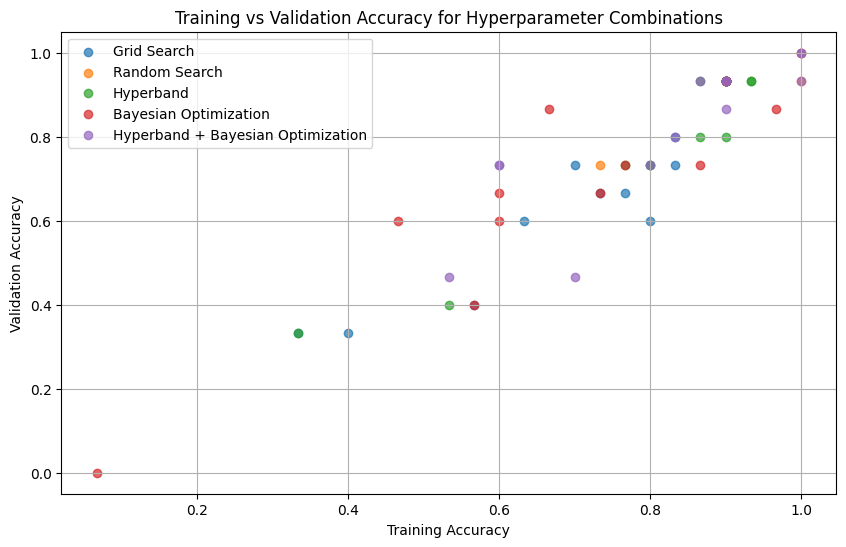


Model Performance Comparison:


Metric,Strategy,Accuracy,F1 Score
0,Bayesian Optimization,0.9,0.897698
1,Grid Search,0.9,0.897698
2,Hyperband,0.9,0.897698
3,Hyperband + Bayesian Optimization,1.0,1.000000
4,Random Search,1.0,1.000000


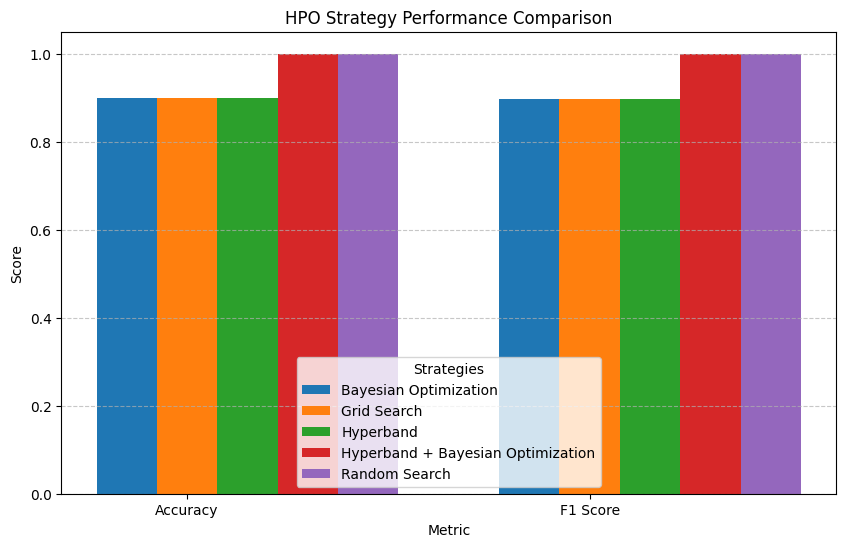

In [23]:
results = automated_hyperparameter_search(train_data, val_data, test_data)